# 39 — Simulate the IMA Default Risk Charge

Measure one-year trading-book default loss at the 99.9% percentile.

PD means Probability of Default and LGD means Loss Given Default. A global factor and a sector-region factor create correlated defaults; issuer-specific shocks retain idiosyncratic risk.

This step uses: Issuer JTD exposures, ratings, PDs, systematic groups and factor loadings.

It produces: A default-loss distribution, 99.9% VaR, tail issuer trace and 12-week capital comparison.

> Basel norm applied: MAR33.18–MAR33.39 require a separate one-year, 99.9% default simulation with two systematic factor types and a 0.03% PD floor.

$$X_i=a_iZ_G+b_iZ_{sector,region}+\sqrt{1-a_i^2-b_i^2}\epsilon_i,\quad Default_i=1\{X_i<\Phi^{-1}(PD_i)\}$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260901T122303Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
issuers=stage('14_ima_drc_issuer_inputs'); distribution=stage('15_ima_drc_loss_distribution'); trace=stage('16_ima_drc_tail_trace'); weekly=stage('17_ima_drc_weekly_history')
display(crore_table(issuers[['obligor','rating','sector','economy','pd','default_threshold','exposure_jtd_inr','systematic_group']],['exposure_jtd_inr']))
current=SUMMARY['ima_drc_current_inr']; average=SUMMARY['ima_drc_average_12_week_inr']; print(f"IMA DRC capital = max(current {money(current)}, 12-week average {money(average)}) = {money(SUMMARY['ima_drc_capital_inr'])}")
print(f'Displayed sample: first 10 of {len(trace):,} retained tail simulations.')
display(trace.head(10))

,obligor,rating,sector,economy,pd,default_threshold,Exposure Jtd (INR crore),systematic_group
0,APPLE,AA,TECHNOLOGY,ADVANCED,0.0010,-3.0902,9.2665,ADVANCED|TECHNOLOGY
1,AXIS_BANK,AA,FINANCIALS,EMERGING,0.0010,-3.0902,2.7359,EMERGING|FINANCIALS
2,CDX_IG_S42,BBB,FINANCIALS,ADVANCED,0.0075,-2.4324,-8.3399,ADVANCED|FINANCIALS
3,CDX_IG_S42_3_7,BBB,FINANCIALS,ADVANCED,0.0075,-2.4324,9.7945,ADVANCED|FINANCIALS
4,EU_TECH,A,TECHNOLOGY,ADVANCED,0.0025,-2.8070,8.4093,ADVANCED|TECHNOLOGY
5,EU_UTILITY,A,UTILITIES,ADVANCED,0.0025,-2.8070,5.7910,ADVANCED|UTILITIES
6,GERMANY,AAA,SOVEREIGN,ADVANCED,0.0004,-3.3528,12.2578,ADVANCED|SOVEREIGN
7,HDFC_BANK,AA,FINANCIALS,EMERGING,0.0010,-3.0902,13.9200,EMERGING|FINANCIALS
8,INDIA,BBB,SOVEREIGN,EMERGING,0.0075,-2.4324,17.0639,EMERGING|SOVEREIGN
9,INDIA_METALS,BB,BASIC_MATERIALS,EMERGING,0.0300,-1.8808,6.7413,EMERGING|BASIC_MATERIALS


IMA DRC capital = max(current INR 31.56 crore, 12-week average INR 29.47 crore) = INR 31.56 crore
Displayed sample: first 10 of 200 retained tail simulations.


,simulation_id,portfolio_default_loss_inr,defaulted_issuer_count,defaulted_issuers
0,518,"320,024,504.1362",2,"INDIA_METALS, RELIANCE"
1,836,"423,250,267.1795",2,"INDIA, RELIANCE"
2,893,"434,243,986.5137",3,"INDIA_SMALLCAP, NIFTY50, RELIANCE"
3,996,"320,024,504.1362",2,"INDIA_METALS, RELIANCE"
4,1717,"315,611,107.6672",2,"INDIA_SMALLCAP, RELIANCE"
5,3502,"423,250,267.1795",2,"INDIA, RELIANCE"
6,4595,"371,243,986.5137",2,"NIFTY50, RELIANCE"
7,5207,"320,024,504.1362",2,"INDIA_METALS, RELIANCE"
8,5346,"315,611,107.6672",2,"INDIA_SMALLCAP, RELIANCE"
9,5764,"350,555,857.6672",2,"CDX_IG_S42_3_7, RELIANCE"


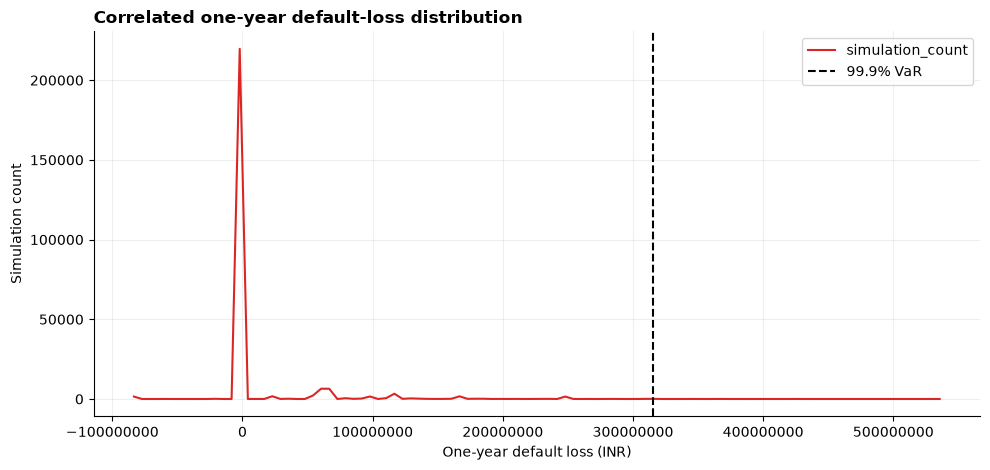

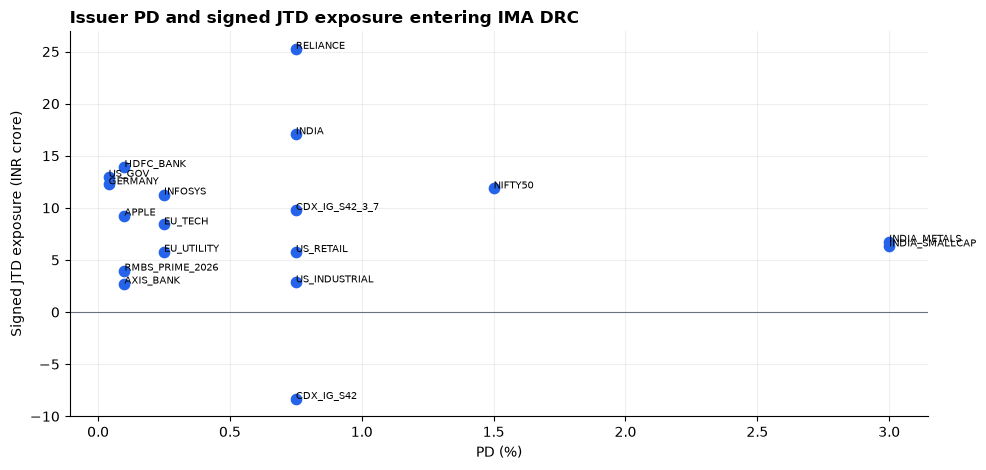

In [3]:
ax=distribution.plot(x='loss_band_inr',y='simulation_count',color='#DC2626',legend=False); ax.axvline(current,color='black',linestyle='--',label='99.9% VaR'); ax.set_xlabel('One-year default loss (INR)'); ax.set_ylabel('Simulation count'); ax.ticklabel_format(axis='x',style='plain'); ax.set_title('Correlated one-year default-loss distribution',loc='left',weight='bold'); ax.legend(); plt.tight_layout(); plt.show()
fig,ax=plt.subplots(); ax.scatter(issuers.pd*100,issuers.exposure_jtd_inr/INR_CRORE,s=55,color='#2563EB');
for _,r in issuers.iterrows(): ax.annotate(r.obligor,(r.pd*100,r.exposure_jtd_inr/INR_CRORE),fontsize=7)
ax.axhline(0,color='#6B7280',linewidth=.8); ax.set_xlabel('PD (%)'); ax.set_ylabel('Signed JTD exposure (INR crore)'); ax.set_title('Issuer PD and signed JTD exposure entering IMA DRC',loc='left',weight='bold'); plt.tight_layout(); plt.show()

The first chart is the simulated one-year portfolio default-loss distribution. Most scenarios have modest loss, while the dashed line marks the 99.9th-percentile tail loss used for current IMA DRC. The second chart separates issuer default likelihood from signed Jump-to-Default exposure. Positive values create loss on default; negative values represent short-credit positions that can offset loss in joint scenarios.